# GT function analysis: Perovskite additives

In [1]:
import os
import re
import glob
import pickle
import datetime
from mordred import Calculator, descriptors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from rdkit import Chem
from rdkit.Chem import Draw
import sys

size_model_path = '/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/0_Create_Ground_Truth_Model/pvkadditives/pvk_rfr_size.pkl'

with open(size_model_path, 'rb') as f:
    rf_model = pickle.load(f)

In [2]:
# from mordred import Calculator, descriptors
from sklearn.ensemble import RandomForestRegressor
# from rdkit.Chem import PandasTools
import pickle

pvk_size_feature_list = ['Reagent1 (ul)','Reagent2 (ul)','Reagent3 (ul)','Reagent4 (ul)','lab_code','ATSC5v', 'AATSC5Z', 'MATS8se']
all_list = ['Reagent1 (ul)','Reagent2 (ul)','Reagent3 (ul)','Reagent4 (ul)','lab_code','ATSC5v', 'AATSC5Z', 'MATS8se','crystal_size']
print(pvk_size_feature_list)
print(all_list)

['Reagent1 (ul)', 'Reagent2 (ul)', 'Reagent3 (ul)', 'Reagent4 (ul)', 'lab_code', 'ATSC5v', 'AATSC5Z', 'MATS8se']
['Reagent1 (ul)', 'Reagent2 (ul)', 'Reagent3 (ul)', 'Reagent4 (ul)', 'lab_code', 'ATSC5v', 'AATSC5Z', 'MATS8se', 'crystal_size']


In [3]:
import pandas as pd
from rdkit import Chem
from mordred import Calculator, descriptors

datapath = '/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/0_Create_Ground_Truth_Model/datasets/combined_compiledData_wmol.csv'
df = pd.read_csv(datapath)
calc = Calculator(descriptors, ignore_3D=True)

unique_molecules = set(df['SMILES'])

features_dict = {}
for smiles in unique_molecules:
    mol = Chem.MolFromSmiles(smiles)
    if mol:  
        features_dict[smiles] = calc(mol)
    else:
        features_dict[smiles] = None  

features_df = pd.DataFrame.from_dict(
    {smiles: list(features_dict[smiles]) if features_dict[smiles] else [None] * len(calc.descriptors)
     for smiles in features_dict},
    orient='index',
    columns=[str(d) for d in calc.descriptors]
)

features_df.reset_index(inplace=True)
features_df.rename(columns={'index': 'SMILES'}, inplace=True)
df = df.merge(features_df, on='SMILES', how='left')


df.columns
# modred feature calculating
X_train = df[pvk_size_feature_list].values

In [4]:
# read files

cycle_count = ['c0','c1','c2','c3','c4'] # 目前跑完的cycle 假設是第0個跑完 想要有地1個cycle的predictor 就設0 假設cycle1結束 就設1 這樣會做cycle1的predictor

methods = ['Random/round1', 'Random/round2', 'Random/round3', 'Random/round4', 'Random/round5','Random/round6','Random/round7', 'Random/round8', 'Random/round9', 'Random/round10',
    'ABC/round1', 'ABC/round2', 'ABC/round3', 'ABC/round4', 'ABC/round5', 'ABC/round6', 'ABC/round7', 'ABC/round8', 'ABC/round9', 'ABC/round10',
    'PSO/round1', 'PSO/round2', 'PSO/round3', 'PSO/round4', 'PSO/round5', 'PSO/round6', 'PSO/round7', 'PSO/round8', 'PSO/round9', 'PSO/round10',]

"""
methods = [
    'ABC/round1', 'ABC/round2', 'ABC/round3', 'ABC/round4', 'ABC/round5', 'ABC/round6', 'ABC/round7', 'ABC/round8', 'ABC/round9', 'ABC/round10',
    'PSO/round1', 'PSO/round2', 'PSO/round3', 'PSO/round4', 'PSO/round5', 'PSO/round6', 'PSO/round7', 'PSO/round8', 'PSO/round9', 'PSO/round10',]
"""

pattern = r"\d{8}\w+_Report\.csv"

parent_directory = '/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives'
preprocessing_for_analysis = os.path.join(parent_directory, '1_Preprocessing_for_Analysis')
make_new_data_predictor = os.path.join(parent_directory, '3_Make_New_Data_Predictor')

#cyclen_list = ['Base_SMILES', 'Ligand_SMILES','Solvent_SMILES','Concentration','Temp_C','yield']

files = []
for i in range(len(cycle_count)):
    for method in methods:
        prediction_folder = os.path.join(preprocessing_for_analysis, method, cycle_count[i])
        for filename in os.listdir(prediction_folder):
            if re.match(pattern, filename):
                file_path = os.path.join(prediction_folder, filename)
                print(file_path)
                pred_df = pd.read_csv(file_path)
                pred_df = pred_df.rename(columns={
                'Reagent1_(ul)': 'Reagent1 (ul)',
                'Reagent2_(ul)': 'Reagent2 (ul)',
                'Reagent3_(ul)': 'Reagent3 (ul)',
                'Reagent4_(ul)': 'Reagent4 (ul)'})
                files.append(pred_df)

files = pd.concat(files, ignore_index=True)
#files = files[files['crystal_size'] >= 1.0]
print(files.columns)



/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round1/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round2/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round3/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round4/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round5/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round6/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round7/c0/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/

/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/PSO/round9/c0/20250721pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/PSO/round10/c0/20250721pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round1/c1/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round2/c1/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round3/c1/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round4/c1/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Random/round5/c1/20250725pvk_Report.csv
/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/1_Preprocessing_for_Analysis/Rando

In [5]:
# concat both Exp data and GT training data

X_train = np.concatenate([files[pvk_size_feature_list].values, X_train], axis = 0)
X_train.shape

(2037, 8)

/home/ianlee/anaconda3/envs/leveler2/lib/python3.8/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


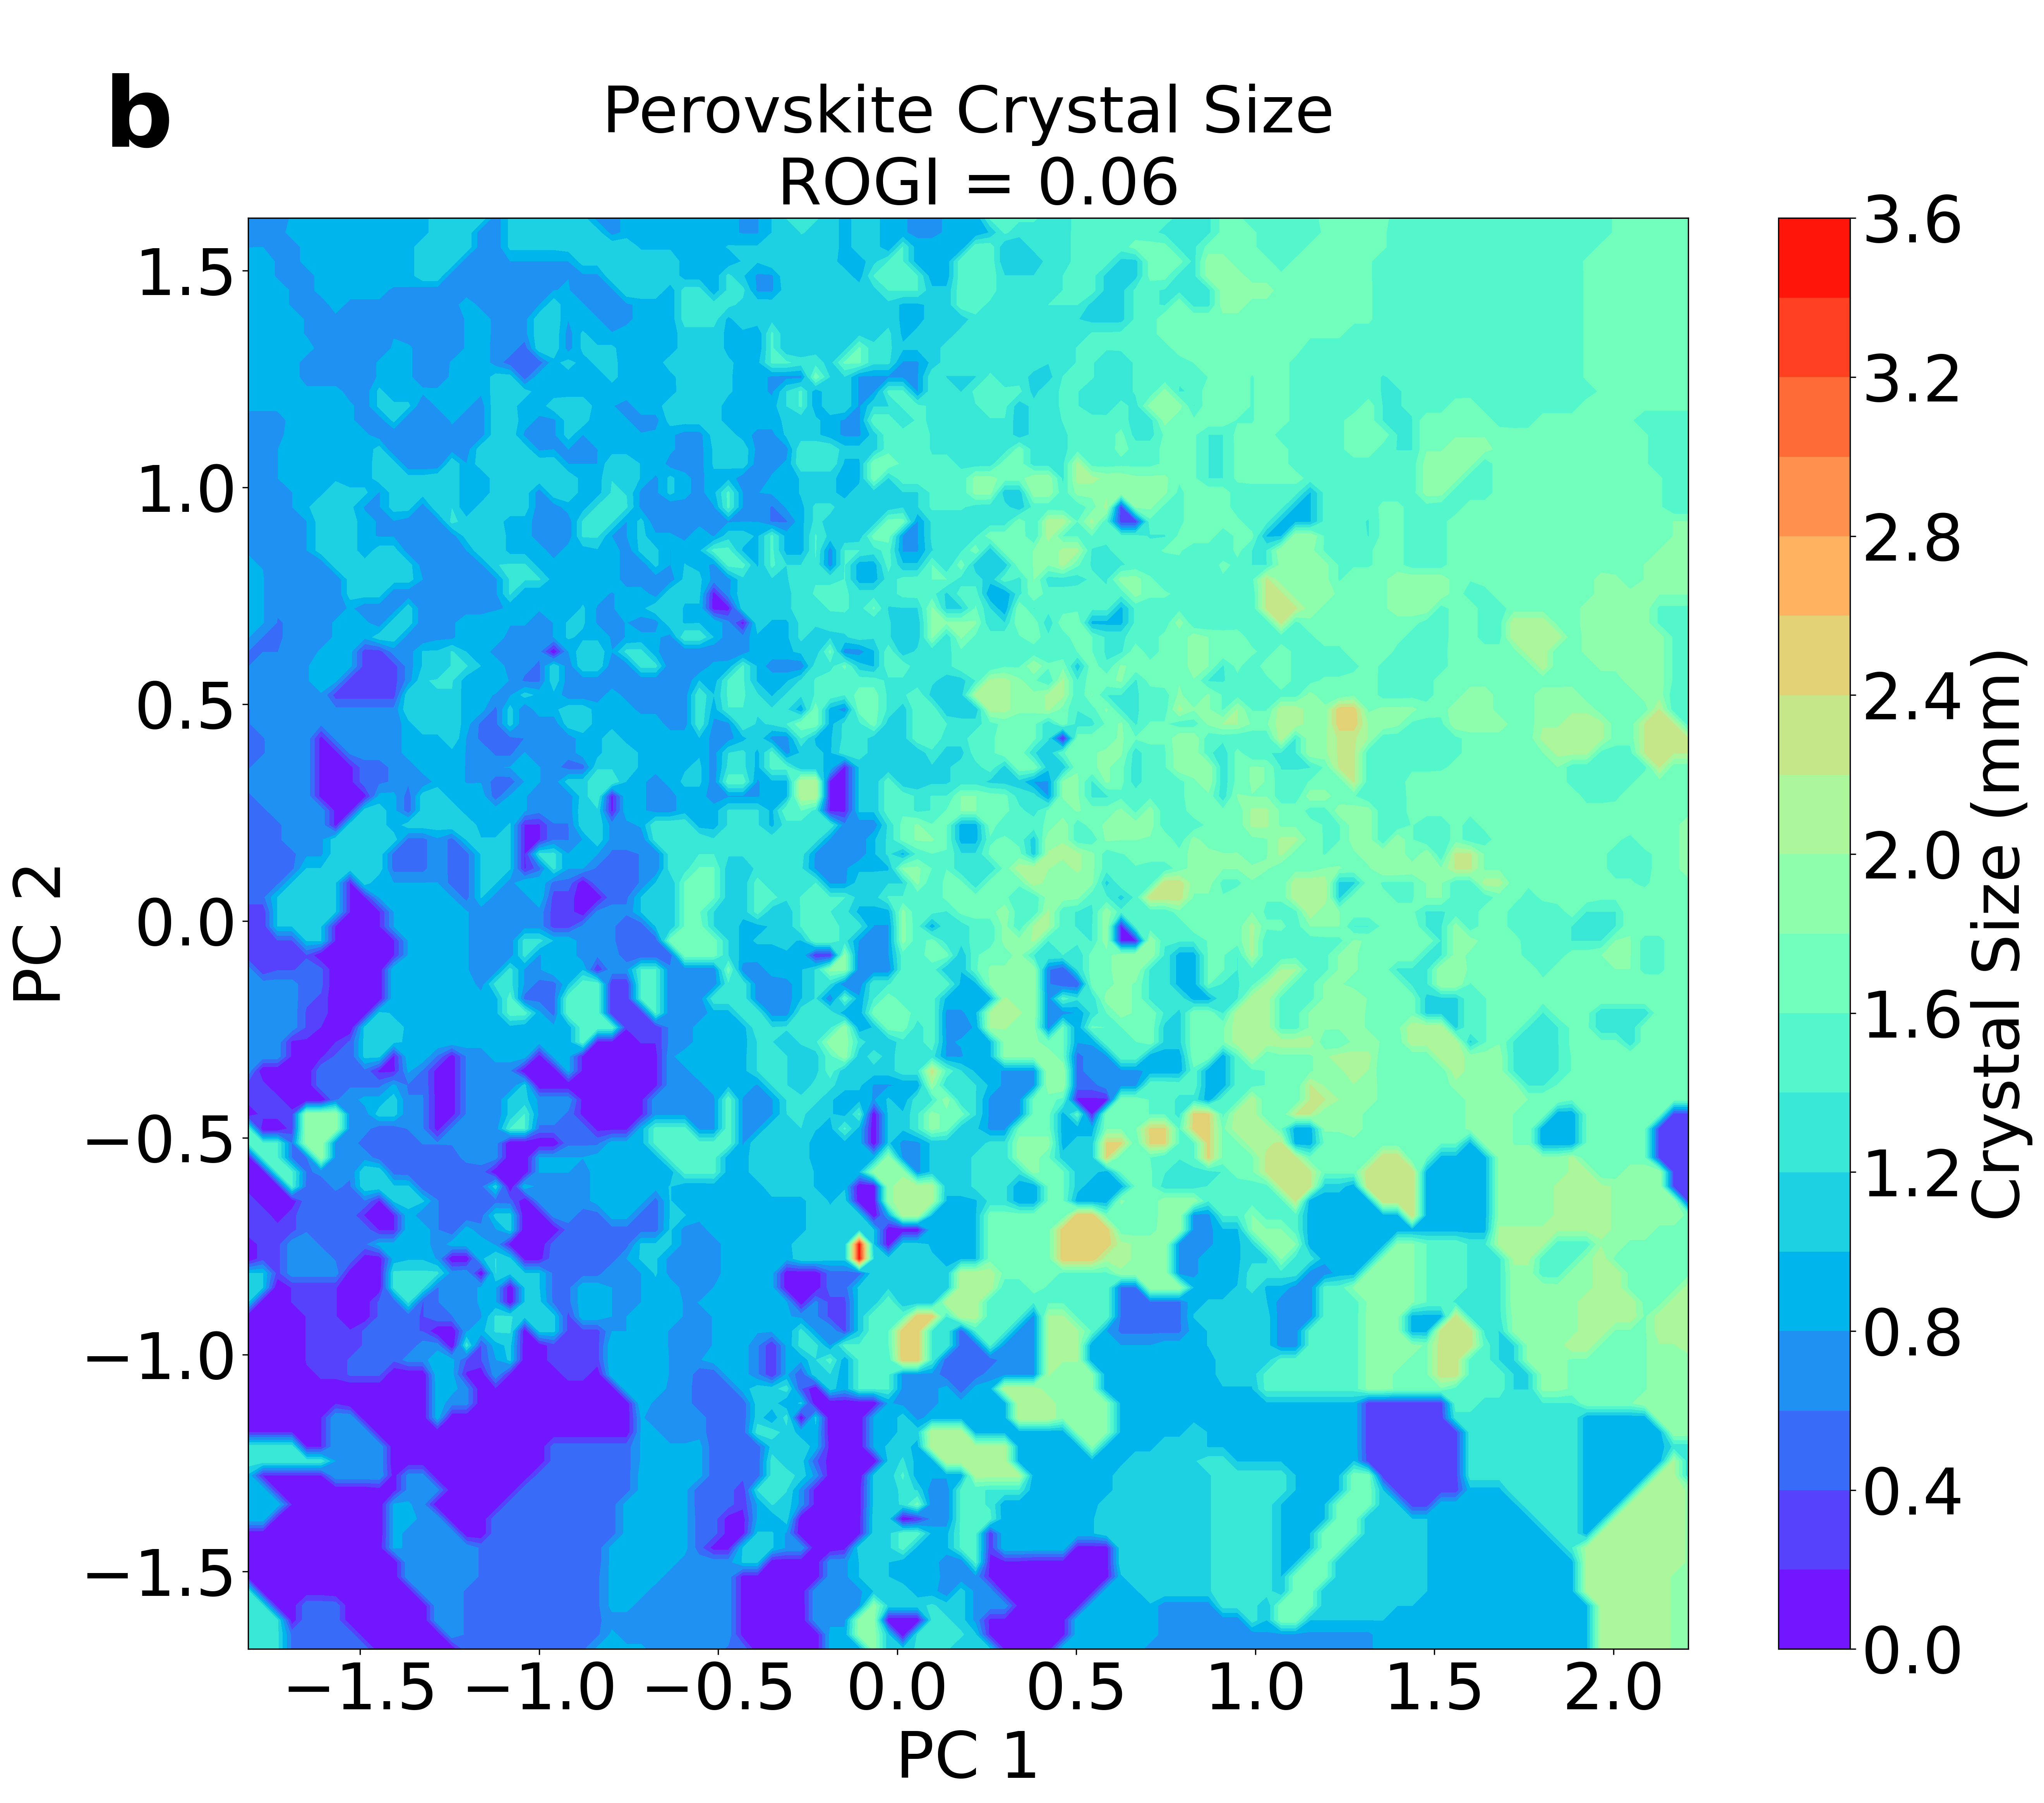

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

grid_size = 100
x_min, x_max = np.percentile(X_train_pca[:,0],[5, 95])
y_min, y_max = np.percentile(X_train_pca[:,1],[5, 95])

xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_size),
                     np.linspace(y_min, y_max, grid_size))
grid_points = np.c_[xx.ravel(), yy.ravel()]

nn = NearestNeighbors(n_neighbors=1).fit(X_train_pca)
distances, indices = nn.kneighbors(grid_points)

X_grid_highdim_scaled = X_train_scaled[indices.flatten()]

X_grid_highdim = scaler.inverse_transform(X_grid_highdim_scaled)

y_pred_grid = rf_model.predict(X_grid_highdim)
y_pred_grid = y_pred_grid.reshape(grid_size, grid_size)

plt.figure(figsize=(20,16), dpi=300)
plt.contourf(xx, yy, y_pred_grid, levels=20, cmap='rainbow')
cbar = plt.colorbar(label='Crystal Size (mm)')
cbar.set_label('Crystal Size (mm)', size=40)
cbar.ax.tick_params(labelsize=40) # Set your desired size here
plt.xlabel('PC 1', fontsize=40)
plt.ylabel('PC 2', fontsize=40)
plt.xticks(fontsize = 40)
plt.yticks(fontsize = 40)
plt.text(-0.1, 1.05, 'b', fontsize=60, fontweight='bold', transform=plt.gca().transAxes)
plt.title('\nPerovskite Crystal Size\n ROGI = 0.06', fontsize=40)
plt.savefig('/home/ianlee/opt_ian/Model_Create_and_Results1/Pvk_additives/4_Final_Anslysis_Like_EDBO/GT_smooth_pvk.jpeg', bbox_inches='tight', dpi=300)
plt.show()